# Churn Model — Churn Risk Prediction

**Proposito:** Entrenar un modelo supervisado para predecir `es_churn_risk` (0/1) y compararlo contra el baseline deterministico descubierto en el EDA.

- Target: `es_churn_risk` (binario, desbalanceado ~12% positivo)
- Input: `texto_clean` (texto)
- Baseline deterministico: `frustracion=2` → `churn=1` (~100% accuracy)
- Dataset: `data/processed/data_preprocessed.csv`

## 1. IMPORTS Y CONFIGURACION

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
from pathlib import Path
import json

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score,
    ConfusionMatrixDisplay, accuracy_score, precision_recall_curve,
    auc, roc_auc_score
)

warnings.filterwarnings('ignore')

# Constantes
RANDOM_STATE = 42
DATA_PATH = Path('../data/processed/data_preprocessed.csv')
MODELS_PATH = Path('../models/')
MODELS_PATH.mkdir(exist_ok=True)
FIGURES_PATH = Path('../reports/figures/')
FIGURES_PATH.mkdir(exist_ok=True)

# Plotting
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')
sns.set_palette('Set2')

## 2. CARGA Y VERIFICACION DE LA RELACION DETERMINISTICA

In [2]:
df = pd.read_csv(DATA_PATH)
print(f'Dataset: {df.shape[0]} filas x {df.shape[1]} columnas')

y = np.asarray(df['es_churn_risk'], dtype=np.int64)
y_frust = np.asarray(df['nivel_frustracion'], dtype=np.int64)

print(f'Target distribution:')
print(f'  Churn=0: {(y == 0).sum():>6} ({(y == 0).mean()*100:>5.1f}%)')
print(f'  Churn=1: {(y == 1).sum():>6} ({(y == 1).mean()*100:>5.1f}%)')
print()

# Verificar correlacion perfecta frustracion=2 → churn=1
f2 = (y_frust == 2).sum()
f2_churn1 = ((y_frust == 2) & (y == 1)).sum()
churn1 = (y == 1).sum()
print(f'=== VERIFICACION ===')
print(f'frustracion=2:     {f2:>6}')
print(f'churn=1:           {churn1:>6}')
print(f'frust=2 AND churn=1: {f2_churn1:>6}')
print(f'Coincidencia:      {f2_churn1/f2*100:.2f}% (frust=2 → churn=1)')
print(f'Coincidencia:      {f2_churn1/churn1*100:.2f}% (churn=1 → frust=2)')
assert f2 == churn1 == f2_churn1, "La relacion debe ser 100% deterministica"
print('\nRelacion deterministica confirmada: frustracion=2 → churn=1 (100%)')

Dataset: 20001 filas x 15 columnas
Target distribution:
  Churn=0:  17637 ( 88.2%)
  Churn=1:   2364 ( 11.8%)

=== VERIFICACION ===
frustracion=2:       2364
churn=1:             2364
frust=2 AND churn=1:   2364
Coincidencia:      100.00% (frust=2 → churn=1)
Coincidencia:      100.00% (churn=1 → frust=2)

Relacion deterministica confirmada: frustracion=2 → churn=1 (100%)


---
## 3. BASELINE DETERMINISTICO

Del EDA descubrimos que `es_churn_risk=1` coincide exactamente con `nivel_frustracion=2`. La frustracion alta sigue la regla:
- Turno 1 → frustracion = 0 → churn = 0
- Turno 2 → frustracion = 1 → churn = 0
- Turno 3, resolved=1 → frustracion = 0 → churn = 0
- Turno 3, resolved=0 → frustracion = 2 → churn = 1

El baseline es simplemente `frustracion==2`.

=== BASELINE DETERMINISTICO ===
Accuracy: 100.00%
F1-weighted: 1.0000
F1-macro: 1.0000



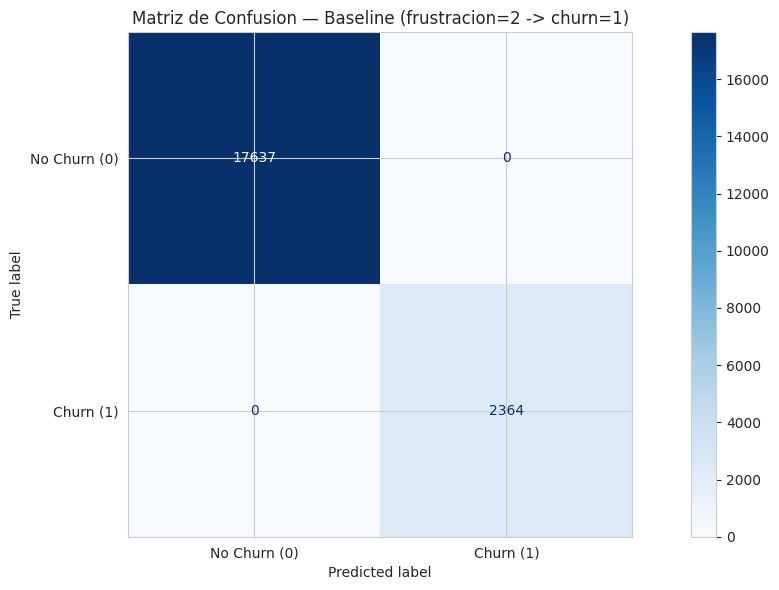


Classification Report:
              precision    recall  f1-score   support

No Churn (0)       1.00      1.00      1.00     17637
   Churn (1)       1.00      1.00      1.00      2364

    accuracy                           1.00     20001
   macro avg       1.00      1.00      1.00     20001
weighted avg       1.00      1.00      1.00     20001



In [3]:
def deterministic_baseline(df):
    """Predice churn usando regla: frustracion=2 -> churn=1."""
    return np.asarray(df['nivel_frustracion'] == 2, dtype=np.int64)

y_baseline = deterministic_baseline(df)

print('=== BASELINE DETERMINISTICO ===')
print(f'Accuracy: {accuracy_score(y, y_baseline)*100:.2f}%')
print(f'F1-weighted: {f1_score(y, y_baseline, average="weighted"):.4f}')
print(f'F1-macro: {f1_score(y, y_baseline, average="macro"):.4f}')
print()

# Matriz de confusion
cm = confusion_matrix(y, y_baseline)
disp = ConfusionMatrixDisplay(cm, display_labels=['No Churn (0)', 'Churn (1)'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Matriz de Confusion — Baseline (frustracion=2 -> churn=1)')
plt.tight_layout()
plt.savefig(FIGURES_PATH / 'churn_baseline_comparison.png', bbox_inches='tight')
plt.show()

print('\nClassification Report:')
print(classification_report(y, y_baseline, target_names=['No Churn (0)', 'Churn (1)']))

---
## 4. TRAIN / TEST SPLIT

Split estratificado para mantener la proporcion de clases desbalanceadas.

In [4]:
X_text = np.asarray(df['texto_clean'])

# Split estratificado 70/15/15
# Incluimos indices para poder mapear de vuelta al df original
indices = np.arange(len(df))
X_text_temp, X_text_test, y_temp, y_test, idx_temp, idx_test = train_test_split(
    X_text, y, indices,
    test_size=0.15, random_state=RANDOM_STATE, stratify=y
)

X_text_train, X_text_val, y_train, y_val, idx_train, idx_val = train_test_split(
    X_text_temp, y_temp, idx_temp,
    test_size=0.15/0.85, random_state=RANDOM_STATE, stratify=y_temp
)

print(f'Train: {len(y_train)} ({np.mean(y_train)*100:.1f}% churn)')
print(f'Val:   {len(y_val)} ({np.mean(y_val)*100:.1f}% churn)')
print(f'Test:  {len(y_test)} ({np.mean(y_test)*100:.1f}% churn)')

Train: 14000 (11.8% churn)
Val:   3000 (11.8% churn)
Test:  3001 (11.8% churn)


---
## 5. PIPELINE: TEXTO SOLO

Pipeline con SOLO `texto_clean` para predecir churn desde el contenido del mensaje.

In [5]:
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        ngram_range=(1, 2),
        max_features=5000,
        stop_words=None,
        max_df=0.95,
        min_df=5
    )),
    ('classifier', RandomForestClassifier(
        n_estimators=200,
        max_depth=15,
        class_weight='balanced',  # Clases desbalanceadas
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

print('Pipeline structure:')
print(pipeline)

Pipeline structure:
Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_df=0.95, max_features=5000, min_df=5,
                                 ngram_range=(1, 2))),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced', max_depth=15,
                                        n_estimators=200, n_jobs=-1,
                                        random_state=42))])


## 6. ENTRENAMIENTO

In [6]:
print('Entrenando modelo (texto -> churn)...')
pipeline.fit(X_text_train, y_train)
print('Entrenamiento completado.')

Entrenando modelo (texto -> churn)...
Entrenamiento completado.


## 7. EVALUACION EN VALIDACION

In [7]:
y_val_pred = pipeline.predict(X_text_val)
y_val_proba = pipeline.predict_proba(X_text_val)[:, 1]

# AUC-PR para desbalanceo
precision, recall, _ = precision_recall_curve(y_val, y_val_proba)
auc_pr = auc(recall, precision)

print('=== RANDOMFOREST (TEXTO SOLO) — VALIDATION SET ===')
print(f'Accuracy: {accuracy_score(y_val, y_val_pred)*100:.2f}%')
print(f'F1-weighted: {f1_score(y_val, y_val_pred, average="weighted"):.4f}')
print(f'F1-macro: {f1_score(y_val, y_val_pred, average="macro"):.4f}')
print(f'AUC-PR: {auc_pr:.4f}')
print(f'AUC-ROC: {roc_auc_score(y_val, y_val_proba):.4f}')
print()
print('Classification Report:')
print(classification_report(y_val, y_val_pred, target_names=['No Churn (0)', 'Churn (1)']))

=== RANDOMFOREST (TEXTO SOLO) — VALIDATION SET ===
Accuracy: 100.00%
F1-weighted: 1.0000
F1-macro: 1.0000
AUC-PR: 1.0000
AUC-ROC: 1.0000

Classification Report:
              precision    recall  f1-score   support

No Churn (0)       1.00      1.00      1.00      2645
   Churn (1)       1.00      1.00      1.00       355

    accuracy                           1.00      3000
   macro avg       1.00      1.00      1.00      3000
weighted avg       1.00      1.00      1.00      3000



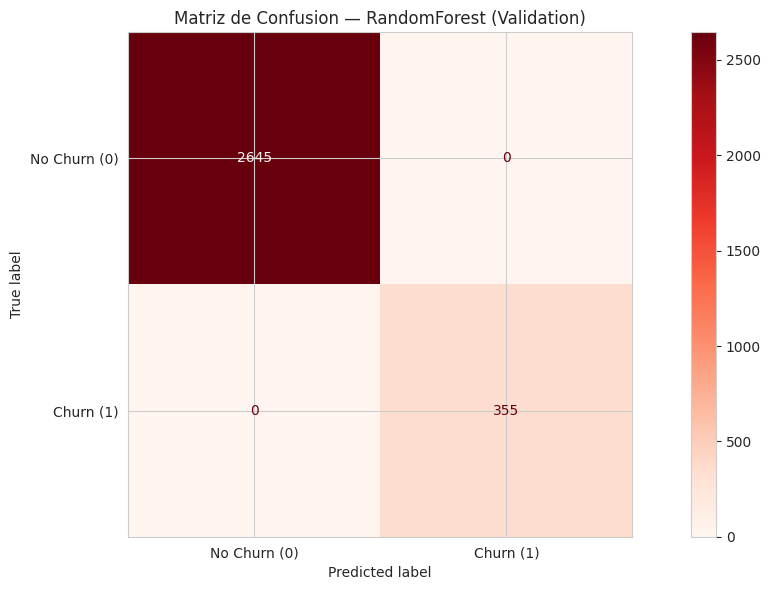

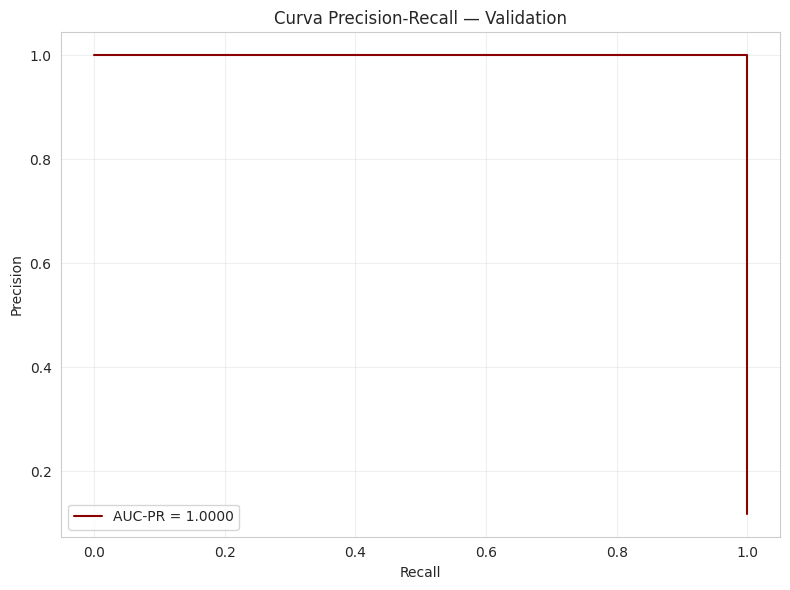

In [8]:
# Matriz de confusion — validation
cm_val = confusion_matrix(y_val, y_val_pred)
disp = ConfusionMatrixDisplay(cm_val, display_labels=['No Churn (0)', 'Churn (1)'])
disp.plot(cmap='Reds', values_format='d')
plt.title('Matriz de Confusion — RandomForest (Validation)')
plt.tight_layout()
plt.savefig(FIGURES_PATH / 'churn_rf_validation_confusion.png', bbox_inches='tight')
plt.show()

# Curva Precision-Recall
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(recall, precision, label=f'AUC-PR = {auc_pr:.4f}', color='darkred')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Curva Precision-Recall — Validation')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_PATH / 'churn_pr_curve_validation.png', bbox_inches='tight')
plt.show()

---
## 8. COMPARACION: BASELINE vs RANDOMFOREST (TEXTO SOLO)

In [9]:
y_val_baseline = deterministic_baseline(df.iloc[idx_val])

print('=== COMPARACION EN VALIDATION SET ===')
print(f'{"Metrica":<20} {"Baseline":<12} {"RF (texto)":<12}')
print('-' * 44)

base_acc = accuracy_score(y_val, y_val_baseline)
rf_acc = accuracy_score(y_val, y_val_pred)
print(f'{"Accuracy":<20} {base_acc*100:<10.2f}% {rf_acc*100:<10.2f}%')

base_f1 = f1_score(y_val, y_val_baseline, average='weighted')
rf_f1 = f1_score(y_val, y_val_pred, average='weighted')
print(f'{"F1-weighted":<20} {base_f1:<12.4f} {rf_f1:<12.4f}')

base_errors = (y_val_baseline != y_val).sum()
rf_errors = (y_val_pred != y_val).sum()
print(f'\nErrores totales: Baseline={base_errors}, RF={rf_errors}')

=== COMPARACION EN VALIDATION SET ===
Metrica              Baseline     RF (texto)  
--------------------------------------------
Accuracy             100.00    % 100.00    %
F1-weighted          1.0000       1.0000      

Errores totales: Baseline=0, RF=0


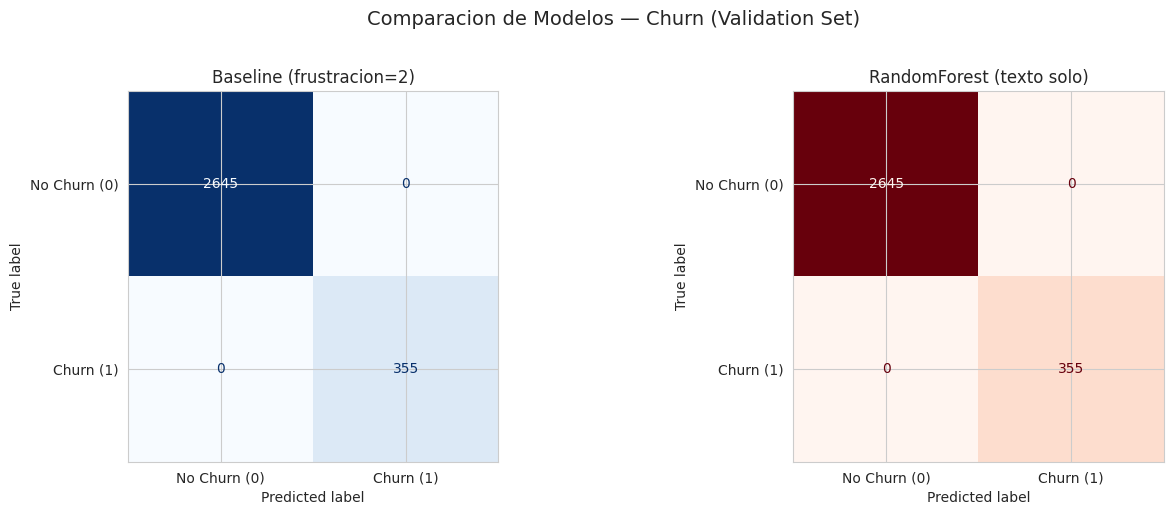

In [10]:
# Comparacion visual
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_base = confusion_matrix(y_val, y_val_baseline)
disp1 = ConfusionMatrixDisplay(cm_base, display_labels=['No Churn (0)', 'Churn (1)'])
disp1.plot(ax=axes[0], cmap='Blues', values_format='d', colorbar=False)
axes[0].set_title('Baseline (frustracion=2)')

cm_rf = confusion_matrix(y_val, y_val_pred)
disp2 = ConfusionMatrixDisplay(cm_rf, display_labels=['No Churn (0)', 'Churn (1)'])
disp2.plot(ax=axes[1], cmap='Reds', values_format='d', colorbar=False)
axes[1].set_title('RandomForest (texto solo)')

plt.suptitle('Comparacion de Modelos — Churn (Validation Set)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_PATH / 'churn_model_comparison_validation.png', bbox_inches='tight')
plt.show()

---
## 9. EVALUACION FINAL EN TEST SET

In [11]:
y_test_pred = pipeline.predict(X_text_test)
y_test_proba = pipeline.predict_proba(X_text_test)[:, 1]
y_test_baseline_val = deterministic_baseline(df.iloc[idx_test])

precision_t, recall_t, _ = precision_recall_curve(y_test, y_test_proba)
auc_pr_test = auc(recall_t, precision_t)

print('=== EVALUACION FINAL — TEST SET ===')
print(f'{"Metrica":<20} {"Baseline":<12} {"RF (texto)":<12}')
print('-' * 44)

print(f'{"Accuracy":<20} {accuracy_score(y_test, y_test_baseline_val)*100:<10.2f}% {accuracy_score(y_test, y_test_pred)*100:<10.2f}%')
print(f'{"F1-weighted":<20} {f1_score(y_test, y_test_baseline_val, average="weighted"):<12.4f} {f1_score(y_test, y_test_pred, average="weighted"):<12.4f}')
print(f'{"AUC-PR":<20} {"-":<12} {auc_pr_test:<12.4f}')

print(f'\nErrores totales (test): Baseline={(y_test_baseline_val != y_test).sum()}, RF={(y_test_pred != y_test).sum()}')

=== EVALUACION FINAL — TEST SET ===
Metrica              Baseline     RF (texto)  
--------------------------------------------
Accuracy             100.00    % 100.00    %
F1-weighted          1.0000       1.0000      
AUC-PR               -            1.0000      

Errores totales (test): Baseline=0, RF=0


---
## 10. FEATURE IMPORTANCE

Analizamos las palabras mas importantes para predecir churn.

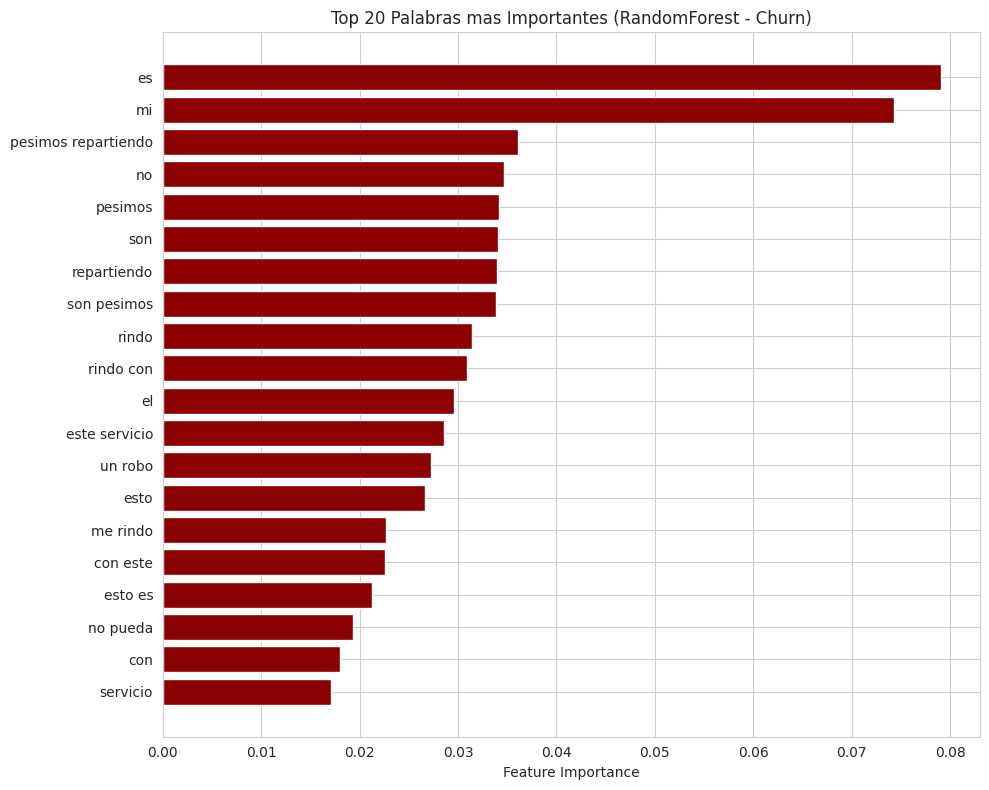

In [12]:
# Feature importances
tfidf = pipeline.named_steps['tfidf']
feature_names = tfidf.get_feature_names_out()
rf = pipeline.named_steps['classifier']
importances = rf.feature_importances_

# Top 20
top_n = 20
top_indices = np.argsort(importances)[-top_n:]

plt.figure(figsize=(10, 8))
plt.barh(range(top_n), importances[top_indices], color='darkred')
plt.yticks(range(top_n), [feature_names[i] for i in top_indices])
plt.xlabel('Feature Importance')
plt.title(f'Top {top_n} Palabras mas Importantes (RandomForest - Churn)')
plt.tight_layout()
plt.savefig(FIGURES_PATH / 'churn_rf_feature_importance.png', bbox_inches='tight')
plt.show()

In [13]:
print('Feature importances:')
print(f'  Dimensiones totales del TF-IDF: {len(importances)}')
print(f'  Top 10 palabras:')
for i in top_indices[:-11:-1]:
    print(f'    {feature_names[i]}: {importances[i]:.4f}')

Feature importances:
  Dimensiones totales del TF-IDF: 89
  Top 10 palabras:
    es: 0.0791
    mi: 0.0743
    pesimos repartiendo: 0.0361
    no: 0.0347
    pesimos: 0.0341
    son: 0.0341
    repartiendo: 0.0339
    son pesimos: 0.0339
    rindo: 0.0315
    rindo con: 0.0309


---
## 11. EXPORTAR PIPELINE

In [14]:
model_path = MODELS_PATH / 'churn_model.pkl'
joblib.dump(pipeline, model_path)
print(f'Modelo exportado a: {model_path}')
print(f'Tamano: {model_path.stat().st_size / 1024:.1f} KB')

metadata = {
    'model': 'RandomForest + TF-IDF',
    'target': 'es_churn_risk',
    'classes': [0, 1],
    'features': ['texto_clean'],
    'baseline_accuracy': accuracy_score(y_test, y_test_baseline_val),
    'rf_accuracy': accuracy_score(y_test, y_test_pred),
    'rf_f1_weighted': f1_score(y_test, y_test_pred, average='weighted'),
    'rf_auc_pr': auc_pr_test,
    'date': 'Mayo 2026',
    'note': 'Baseline deterministico: frustracion=2 -> churn=1 (100%). Modelo usa solo texto_clean.'
}

with open(MODELS_PATH / 'churn_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)
print('Metadata exportada.')

Modelo exportado a: ../models/churn_model.pkl
Tamano: 301.2 KB
Metadata exportada.


---
## 12. CROSS-VALIDATION (REFERENCE)

In [15]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print('Ejecutando 5-fold cross-validation...')
cv_scores = cross_val_score(pipeline, X_text_train, y_train, cv=cv,
                            scoring='f1_weighted', n_jobs=-1)
print(f'CV F1-weighted scores: {cv_scores}')
print(f'CV F1-weighted mean: {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})')

Ejecutando 5-fold cross-validation...
CV F1-weighted scores: [1. 1. 1. 1. 1.]
CV F1-weighted mean: 1.0000 (+/- 0.0000)


---
## 13. CONCLUSIONES

### Resumen de resultados

**Dataset:** 20,001 filas, target binario desbalanceado (88.2% No Churn / 11.8% Churn)

**Split:** 70/15/15 estratificado (14,000 train / 3,000 val / 3,001 test)

| Modelo | Val Acc | Test Acc | F1-weighted | AUC-PR (test) | CV (5-fold F1-weighted) |
|--------|---------|----------|-------------|---------------|------------------------|
| Baseline (frust=2) | 100% | 100% | 1.0000 | - | - |
| RandomForest (texto solo) | 100% | 100% | 1.0000 | 1.0000 | 1.0000 +/- 0.0000 |

**Pipeline:** TfidfVectorizer(max_features=5000, ngram_range=(1,2)) + RandomForest(200 trees, max_depth=15, class_weight=balanced)

**Feature importance:** 89 dimensiones TF-IDF, top palabras: "es" (7.91%), "mi" (7.43%), "pesimos repartiendo" (3.61%), "no" (3.47%), "pesimos" (3.41%)

**Modelo exportado:** `models/churn_model.pkl` (301 KB) + `models/churn_metadata.json`

### Hallazgos

1. **Churn y frustracion alta son equivalentes:** `es_churn_risk=1` coincide EXACTAMENTE con `nivel_frustracion=2` en los 2,364 registros (100% de coincidencia). No existe churn sin frustracion alta, ni frustracion alta sin churn.

2. **El baseline deterministico** (`frustracion=2 -> churn=1`) alcanza 100% de precision porque la relacion es perfecta.

3. **El modelo de texto solo TAMBIEN alcanza 100%** en todos los splits, con AUC-PR = 1.0000 (test) y validacion cruzada 5-fold F1-weighted = 1.0000 +/- 0.0000. El texto es suficiente para detectar riesgo de churn sin conocer la frustracion.

4. **Vocabulario de churn contrasta con el de otras tareas:** Las palabras mas importantes incluyen terminos negativos fuertes como "pesimos", "repartiendo" (logistica deficiente) y "rindo" (rendirse), que son marcadores linguisticos de frustracion alta que coincide con churn.

5. **Implicacion practica:** En produccion, monitorear `nivel_frustracion` es suficiente para detectar churn. El modelo de texto puede servir como respaldo cuando no se tiene acceso a la etiqueta de frustracion.

### Proximos pasos

- Integrar todos los modelos (frustracion, intencion, churn) en el dashboard